---

### №3 **(2 балла)**

---

### **УСЛОВИЕ**

Обучите модель линейной регрессии на данных согласно вашему варианту. Выведите угловой коэффициент, точку пересечения с осью ординат и точность.


**ВАРИАНТ 3:**
$$ Y = 4 \cdot x + random(13) $$

---

### **РЕШЕНИЕ**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [2]:
np.random.seed(0)                    # фиксируем генератор
x = np.arange(0, 20)                 # x = 0,1,...,20
noise = np.random.randint(0, 13, size=x.shape)  # random(13)
y = 4 * x + noise

# ------------------------------------------------------------------

X = x.reshape(-1, 1)         # превращаем в столбец признаков
model = LinearRegression()
model.fit(X, y)

k = model.coef_[0]           # угловой коэффициент
b = model.intercept_         # точка пересечения с осью Y
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)     # точность R^2

print("k =", k)
print("b =", b)
print("R^2 =", r2)

k = 4.06015037593985
b = 5.528571428571425
R^2 = 0.9786289716864784


---

### №4 **(3 балла)**

---

### **УСЛОВИЕ**

Скачайте датасет https://cloud.mail.ru/public/SAi2/M1AzFm7BC, в котором по дням
записаны календарная информация и погодные условия, характеризующие
автоматизированные пункты проката велосипедов, а также число прокатов в этот день (это
значение необходимо предсказывать).
Для каждого дня проката известны следующие признаки (как они были указаны в источнике
данных):

- season: 1 - весна, 2 - лето, 3 - осень, 4 - зима
- yr: 0 - 2011, 1 - 2012
- mnth: от 1 до 12
- holiday: 0 - нет праздника, 1 - есть праздник
- weekday: от 0 до 6
- workingday: 0 - нерабочий день, 1 - рабочий день
- weathersit: оценка благоприятности погоды от 1 (чистый, ясный день) до 4 (ливень, туман)
- temp: температура в Цельсиях
- atemp: температура по ощущениям в Цельсиях
- hum: влажность
- windspeed(mph): скорость ветра в милях в час
- windspeed(ms): скорость ветра в метрах в секунду
- cnt: количество арендованных велосипедов (это целевой признак, его мы будем предсказывать) 

Выполните следующие шаги:

1. Покажите на графиках, как целевой признак зависит от остальных. Каков характер
зависимости числа прокатов от месяца? Укажите один или два признака, от которых
число прокатов скорее всего зависит линейно.

2. Есть ли в данных похожие или дублирующие друг друга признаки? Как вы можете
показать их похожесть? Удалите такие признаки из датасета.

3. Разбейте данные на тренировочные и тестовые. Обучите модель линейной
регрессии. Выведите точность предсказания модели для тестовых данных. 

---

### **РЕШЕНИЕ**

In [3]:
df_bikes = pd.read_csv('bikes_rent.csv', sep=',')

df_bikes = df_bikes.drop(columns=['Unnamed: 13'])

# В файле десятичный разделитель — запятая, поэтому надо привести к float
cols_float = ['temp', 'atemp', 'hum', 'windspeed(mph)', 'windspeed(ms)', 'cnt']
for c in cols_float:
    df_bikes[c] = df_bikes[c].astype(str).str.replace(',', '.').astype(float)

df_bikes.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed(mph),windspeed(ms),cnt
0,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,4.805490,985.0
1,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,7.443949,801.0
2,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,7.437060,1349.0
3,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,4.800998,1562.0
4,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,5.597810,1600.0


1. Покажите на графиках, как целевой признак зависит от остальных. Каков характер
зависимости числа прокатов от месяца? Укажите один или два признака, от которых
число прокатов скорее всего зависит линейно.

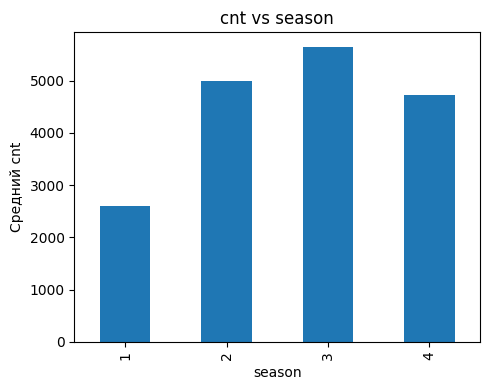

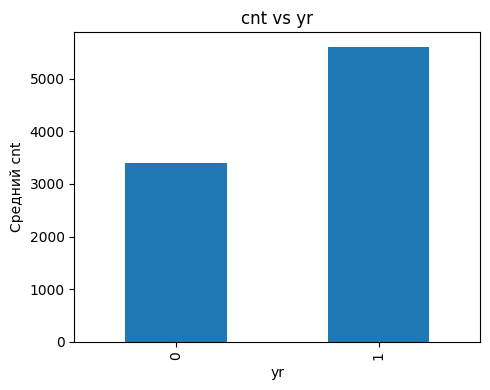

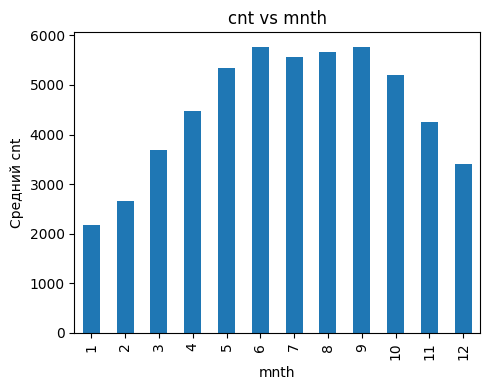

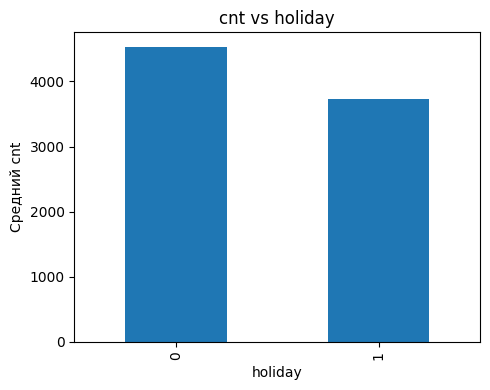

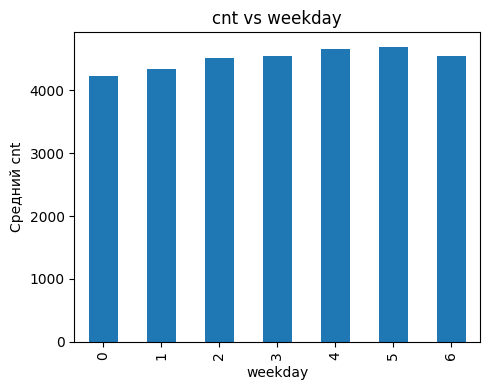

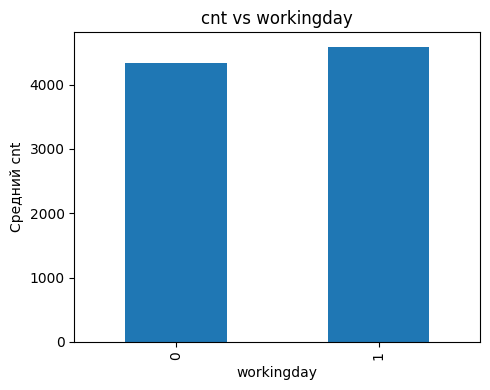

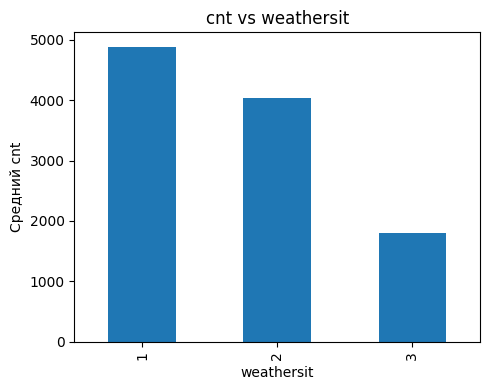

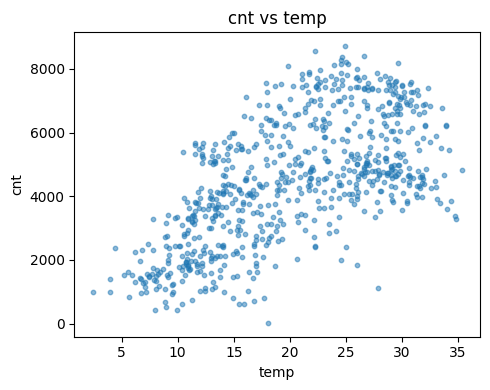

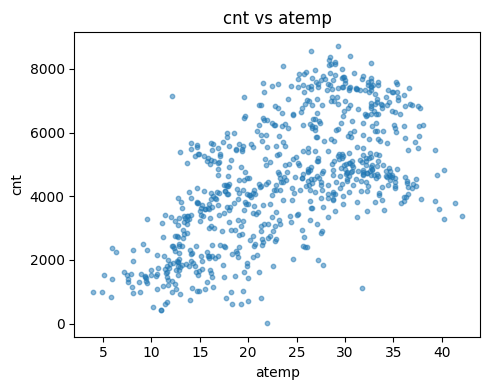

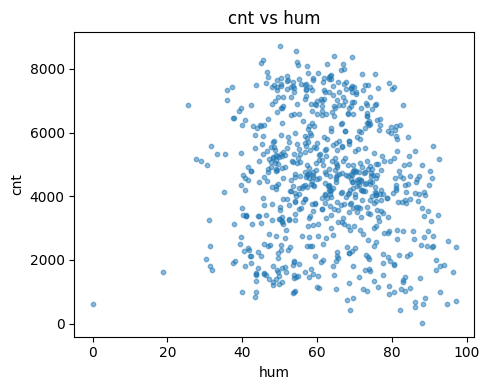

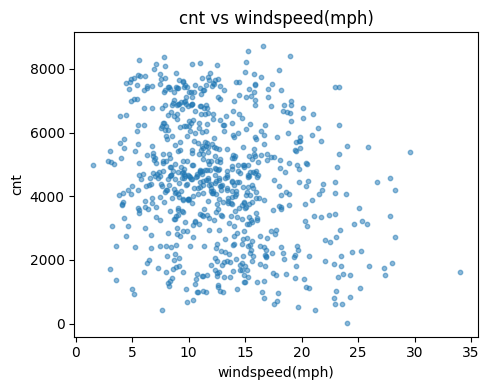

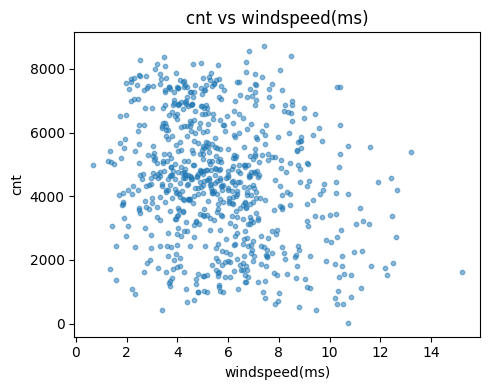

In [4]:
target = 'cnt'
features = [c for c in df_bikes.columns if c != target]

for col in features:
    plt.figure(figsize=(5, 4))
    if df_bikes[col].nunique() <= 12:        # сезон, месяц, день недели и т.п.
        df_bikes.groupby(col)[target].mean().plot(kind='bar')
        plt.ylabel('Средний cnt')
    else:                                    # числовые признаки
        plt.scatter(df_bikes[col], df_bikes[target], s=10, alpha=0.5)
        plt.ylabel('cnt')
    plt.xlabel(col)
    plt.title(f'cnt vs {col}')
    plt.tight_layout()
    plt.show()

**Пояснения**

- Для **категориальных** признаков (yr, season, holiday, workingday, weekday, mnth, weathersit) использованы столбчатые диаграммы средней cnt. 
    - Это удобно, потому что для каждого значения категории (год, сезон, месяц и т.д.) видно среднее число прокатов, и график не перегружается точками.
- Для **количественных** признаков (temp, atemp, hum, windspeed(mph), windspeed(ms)) использованы диаграммы рассеяния.
    - Они показывают, как распределены отдельные наблюдения и позволяет визуально оценить форму зависимости (линейная, нелинейная, отсутствует).

**ПО КАЖДОМУ ГРАФИКУ ОТДЕЛЬНО**

- **cnt vs season**
    - Весной (1) прокатов меньше всего, летом (2) и особенно осенью (3) — максимум, зимой (4) — спад.
    - Число прокатов сильно зависит от сезона: в тёплое время года спрос выше.

- **cnt vs yr**
    - В 2012 году (yr = 1) среднее число прокатов заметно выше, чем в 2011 (yr = 0).
    - Можно сделать вывод, что популярность аренды велосипедов с течением времени выросла.

- **cnt vs mnth**
    - График по месяцам имеет «колокол»: минимум зимой (1–2, 12), затем рост к весне и максимум летом (6–9), потом снижение осенью.
    - Это отражает ярко выраженную сезонность спроса: чем теплее месяц, тем больше прокатов.

- **cnt vs holiday**
    - В праздничные дни среднее число прокатов меньше, чем в обычные.
    - Возможно, в праздники люди чаще остаются дома или уезжают, поэтому аренда велосипедов падает.

- **cnt vs weekday**
    - Среднее число прокатов по дням недели меняется слабо; немного выше в середине недели и в пятницу
    - Сильной зависимости от конкретного дня недели не наблюдается.

- **cnt vs workingday**
    - Разница между рабочими и нерабочими днями небольшая, но в рабочие дни прокатов немного больше.
    - Это может говорить о том, что велосипеды используют и для поездок по делам/на работу, и для отдыха.

- **cnt vs weathersit**
    - При «хорошей» погоде (weathersit = 1) среднее число прокатов максимальное; при ухудшении погоды (2, 3) оно заметно падает.
    - Погода в целом сильно влияет на спрос: чем хуже условия, тем меньше прокатов.

- **cnt vs temp**
    - Точки образуют вытянутую вверх диагональную «полосу»: с ростом температуры количество прокатов увеличивается почти линейно до определённого уровня.
    - Можно считать, что зависимость числа прокатов от temp близка к линейной (в разумном диапазоне температур).

- **cnt vs atemp**
    - Картина очень похожа на temp: с ростом «ощущаемой температуры» количество прокатов растёт почти линейно.
    - Признак atemp также даёт почти линейную связь с целевой переменной.

- **cnt vs hum**
    - Облако точек достаточно размыто, чёткой линейной зависимости не видно; при высокой влажности разброс cnt большой.
    - Можно сказать, что влияние влажности на число прокатов слабое и явно нелинейное.

- **cnt vs windspeed(mph) / windspeed(ms)**
    - Облако точек почти круглое, без выраженного наклона: при разных скоростях ветра cnt сильно колеблется.
    - Линейной зависимости между числом прокатов и скоростью ветра практически нет; ветер влияет слабо.



2. Есть ли в данных похожие или дублирующие друг друга признаки? Как вы можете
показать их похожесть? Удалите такие признаки из датасета.

In [5]:
# удаление дубликатов
corr = df_bikes[['temp', 'atemp', 'windspeed(mph)', 'windspeed(ms)', 'cnt']].corr()
print(corr)

                    temp     atemp  windspeed(mph)  windspeed(ms)       cnt
temp            1.000000  0.991702       -0.157944      -0.157944  0.627494
atemp           0.991702  1.000000       -0.183643      -0.183643  0.631066
windspeed(mph) -0.157944 -0.183643        1.000000       1.000000 -0.234545
windspeed(ms)  -0.157944 -0.183643        1.000000       1.000000 -0.234545
cnt             0.627494  0.631066       -0.234545      -0.234545  1.000000


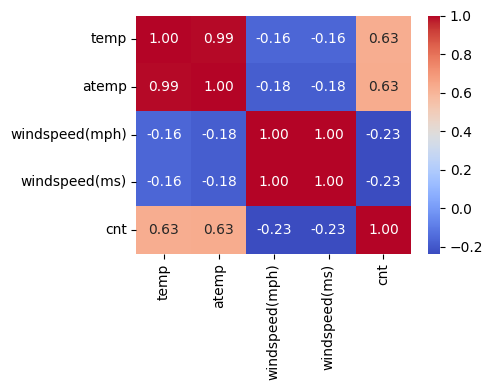

In [7]:
plt.figure(figsize=(5,4))
sb.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.tight_layout()
plt.show()

**ПОЯСНЕНИЯ**, рассмаьотваем корреляции между парами признаков
- Корреляция между `temp` и `atemp` почти равна `1` (0.99), => 
    - **эти признаки практически одинаковы и дублируют друг друга.**
- Корреляция между `windspeed(mph)` и `windspeed(ms)` тоже равна `1.00` =>
    - т.е. это действительно **это одна и та же величина в разных единицах измерения.**
- Корреляция `temp`/`atemp` с `cnt` `0.63` =>
    - достаточно сильная положительная связь, число прокатов растёт с температурой.
    - но при этом данная корреляция действительно имеет смысл (в отличии от предыдущих двух)
- Скорость ветра `(windspeed(mph)` и `windspeed(ms)` с `cnt` связана **слабо и отрицательно** (`−0.23`) => 
    - то есть сильный ветер немного уменьшает число прокатов, но эффект небольшой.

In [8]:
df_model = df_bikes.drop(columns=['atemp', 'windspeed(mph)'])
# откидываем бесполезное

df_model.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed(ms),cnt
0,1,0,1,0,6,0,2,14.110847,80.5833,4.805490,985.0
1,1,0,1,0,0,0,2,14.902598,69.6087,7.443949,801.0
2,1,0,1,0,1,1,1,8.050924,43.7273,7.437060,1349.0
3,1,0,1,0,2,1,1,8.200000,59.0435,4.800998,1562.0
4,1,0,1,0,3,1,1,9.305237,43.6957,5.597810,1600.0


3. Разбейте данные на тренировочные и тестовые. Обучите модель линейной
регрессии. Выведите точность предсказания модели для тестовых данных.


In [9]:
# Обучение регрессионной модели
X = df_model.drop(columns=['cnt'])
y = df_model['cnt']

In [10]:
# разбиваем данные на тренировочные и тестовые
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,     
    random_state=42,
    shuffle=True
)

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R² на тестовой выборке:", r2)
print("MSE на тестовой выборке:", mse)

R² на тестовой выборке: 0.8231919187657435
MSE на тестовой выборке: 703513.357345726


---

### №5 **(3 балла)**

---

### **УСЛОВИЕ**

С сайта https://www.kaggle.com/ скачайте датасет на ваш выбор для обучения модели
линейной регрессии. Выполните следующие действия:

1. Опишите выбранный набор данных: контекст данных, какие данные есть в наборе,
как можно будет использовать полученные результаты предсказания.

2. Выберите выходную прогнозируемую переменную.

3. Постройте линейную регрессионную модель с несколькими значимыми
параметрами (оцените корреляции между признаками, последовательно добавляйте
признаки и сравнивайте качество получаемых моделей, оцените адекватность
модели).

4. Интерпретируйте результаты моделирования (что значит полученная формула,
какие переменные вносят больший вклад).

5. Спрогнозируйте несколько новых значений с помощью построенной модели.

---

### **РЕШЕНИЕ**

---

1. Опишите выбранный набор данных: контекст данных, какие данные есть в наборе,
как можно будет использовать полученные результаты предсказания.

    - **ОТВЕТ:** Набор данных описывает химические свойства португальских красных вин сорта «Vinho Verde» и их сенсорную качество‑оценку экспертами.​​

    - Данные собраны исследователями для анализа того, как физико‑химические характеристики вина влияют на оценку качества дегустаторами.​

    - Каждый объект — один образец красного вина; целевая переменная quality — средняя экспертная оценка по шкале от 0 (очень плохо) до 10 (отлично).​​

    - В файле 1599 строк и 12 столбцов.​​
    
    - Признаки (все **числовые**, **непрерывные**):
        - `fixed acidity`, `volatile acidity`, `citric acid` — различные виды кислотности.​
        - `residual sugar` — остаточный сахар.​
        - `chlorides` — содержание солей/хлоридов.​
        - `free sulfur dioxide`, `total sulfur dioxide` — свободный и общий диоксид серы (консерванты).​
        - `density` — плотность вина.​
        - `pH` — кислотность по шкале pH.​
        - `sulphates` — сульфаты, связанные с антиоксидантными свойствами.​
        - `alcohol` — процентное содержание алкоголя.​
        - `quality` — целевой признак, экспертная оценка качества (целое число 3–8 для этого поднабора).​
    
    - Как можно использовать предсказания:
        - Поддержка виноделов: модель может подсказать, как изменение технологических параметров (кислотность, сахар, SO₂ и т.п.) повлияет на ожидаемое качество, и помочь оптимизировать рецепт или режим выдержки.​
        - Автоматический контроль качества: по результатам лабораторного анализа можно автоматически оценивать партию вина и выявлять образцы с потенциально низким качеством ещё до дегустации.​
        - Маркетинг и ценообразование: прогнозируемая оценка качества может использоваться как один из факторов при установлении цены и позиционировании продукта на рынке.​

2. Выберите выходную прогнозируемую переменную.
    - **ОТВЕТ:** `quality` — целевой признак, экспертная оценка качества (целое число 3–8 для этого поднабора).

In [12]:
df_wine = pd.read_csv('winequality-red.csv', sep=',')

df_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [13]:
df_wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [14]:
df_wine.shape

(1599, 12)

In [15]:
corr_with_q = df_wine.corr(numeric_only=True)['quality'].sort_values(ascending=False)

# убираем сам quality
corr_with_q = corr_with_q.drop('quality')

print(corr_with_q)

alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


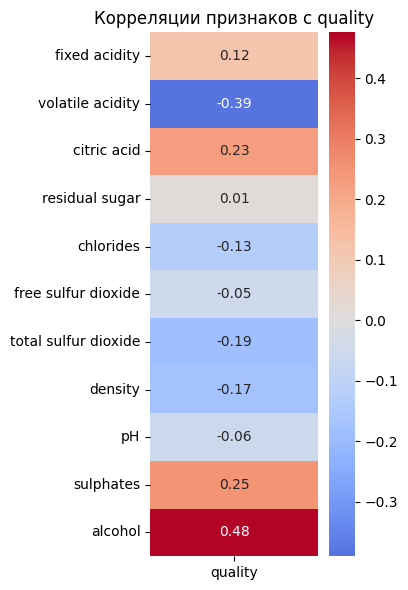

In [16]:
corr_with_q = df_wine.corr(numeric_only=True)['quality'].drop('quality')

plt.figure(figsize=(4,6))
sb.heatmap(
    corr_with_q.to_frame(),   # превращаем Series в DataFrame
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Корреляции признаков с quality')
plt.tight_layout()
plt.show()

**ПОЯСНЕНИЯ**
- Наибольшую **положительную корреляцию** с качеством имеет `alcohol` (≈`0.48`) => 
    - чем выше содержание алкоголя, тем выше средняя оценка вина дегустаторами.
- Дальше идут `sulphates` (≈`0.25`) и `citric acid` (≈`0.23`) =>
    - более высокие значения сульфатов и лимонной кислоты умеренно связаны с лучшим качеством, вероятно, за счёт большей стабильности и свежести вкуса.​
- `Volatile acidity` имеет **самую сильную отрицательную корреляцию** (≈`−0.39`) =>
    - рост летучей кислотности (уксусные тона) заметно ухудшает оценку качества.
- **Отрицательные корреляции** также у `total sulfur dioxide` (≈`−0.19`) и density (≈`−0.17`) => 
    - вина с более высокой плотностью и большим количеством SO₂, как правило, оцениваются ниже.​
- Остальные признаки (`fixed acidity`, `residual sugar`, `chlorides`, `free sulfur dioxide`, `pH`)
    - имеют слабую по модулю связь с качеством (|r| < `0.15`), то есть сами по себе почти **не объясняют вариацию оценок**.​​

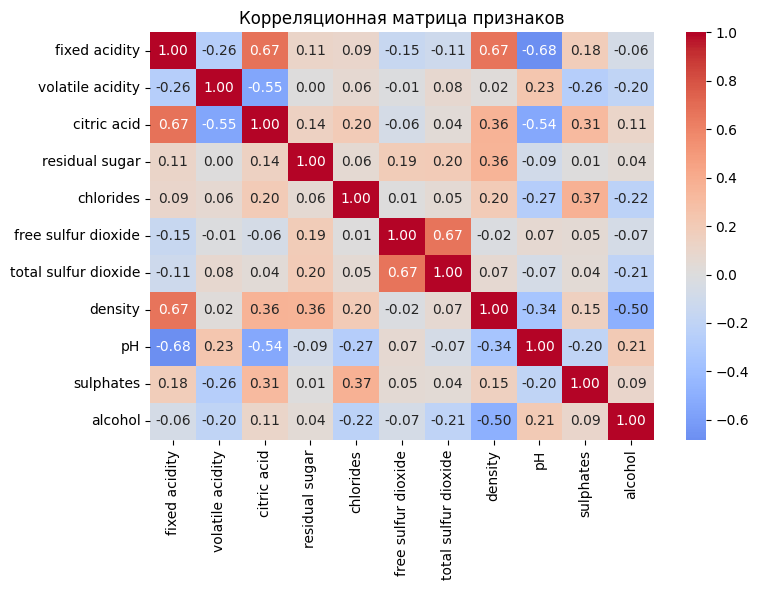

In [17]:
corr = df_wine.corr(numeric_only=True)

# убираем quality из строк и столбцов
corr_no_q = corr.drop(index='quality', columns='quality')

plt.figure(figsize=(8,6))
sb.heatmap(
    corr_no_q,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

**ПОЯСНЕНИЯ**
- Между `fixed acidity`, `citric acid` и `density` наблюдаются довольно сильные положительные корреляции (около 0.6–0.7),
    - а с `pH` — сильные отрицательные, что отражает физический смысл: более высокая кислотность даёт большую плотность и меньший pH.​​

- `Free sulfur dioxide` и `total sulfur dioxide` сильно коррелируют друг с другом (r ≈ 0.67) =>
    - они частично дублируют информацию 

3. Постройте линейную регрессионную модель с несколькими значимыми
параметрами (оцените корреляции между признаками, последовательно добавляйте
признаки и сравнивайте качество получаемых моделей, оцените адекватность
модели).

In [18]:
feature_sets = [
    ['alcohol'],
    ['alcohol', 'volatile acidity'],
    ['alcohol', 'volatile acidity', 'sulphates'],
    ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'density', 'total sulfur dioxide'],
]

for i, feats in enumerate(feature_sets, start=1):
    X = df_wine[feats]
    y = df_wine['quality']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, shuffle=True
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    print(f'Модель {i}, признаки: {feats}')
    print('  R² =', round(r2, 3))
    print('  MSE =', round(mse, 3))
    print('  Коэффициенты:', model.coef_)
    print('  Intercept:', model.intercept_)
    print()

Модель 1, признаки: ['alcohol']
  R² = 0.191
  MSE = 0.5
  Коэффициенты: [0.3742707]
  Intercept: 1.7272199859166113

Модель 2, признаки: ['alcohol', 'volatile acidity']
  R² = 0.318
  MSE = 0.422
  Коэффициенты: [ 0.32850002 -1.29614915]
  Intercept: 2.893582602282265

Модель 3, признаки: ['alcohol', 'volatile acidity', 'sulphates']
  R² = 0.348
  MSE = 0.403
  Коэффициенты: [ 0.32366665 -1.15394768  0.58590009]
  Intercept: 2.481606249699124

Модель 4, признаки: ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'density', 'total sulfur dioxide']
  R² = 0.35
  MSE = 0.402
  Коэффициенты: [ 3.11616295e-01 -1.18063505e+00  6.35148595e-01 -1.03959411e-01
  6.51135475e+00 -2.45975500e-03]
  Intercept: -3.758088955967003



**ПОЯСНЕНИЯ**

---

Динамика качества моделей
- Модель 1 (alcohol): 
    - R² = 0.191
    - MSE = 0.50
    - Использование только содержания алкоголя объясняет примерно 19% вариации качества; коэффициент положительный (0.37), значит больше алкоголя → выше прогноз качества.​​

- Модель 2 (alcohol, volatile acidity): 
    - R² вырастает до 0.318
    - MSE падает до 0.422
    - Отрицательный коэффициент при volatile acidity (−1.30) показывает, что рост летучей кислотности сильно снижает оценку; модель становится заметно точнее.​​

- Модель 3 (alcohol, volatile acidity, sulphates): 
    - R² = 0.348
    - MSE = 0.403
    - Положительный коэффициент при sulphates (~0.59) означает, что более высокое содержание сульфатов умеренно повышает ожидаемое качество; добавление признака даёт ощутимое, но уже не такое большое улучшение.​​

- Модель 4 (6 признаков): 
    - R² = 0.35
    - MSE = 0.402
    - Добавление citric acid, density, total sulfur dioxide почти не повышает R²: прирост с 0.348 до 0.350 минимален, а ошибка почти не меняется, что говорит о насыщении модели и возможной мультиколлинеарности между признаками.

---

- Знаки коэффициентов согласуются с предметной областью и корреляциями:
    - `алкоголь` и `сульфаты` повышают качество,
    - `летучая кислотность`, `высокая плотность` и `большой total sulfur dioxide` — снижают,
    - поэтому модель можно считать интерпретируемой и адекватной, хотя и не полностью описывающей все факторы качества.

---

4. Интерпретируйте результаты моделирования (что значит полученная формула,
какие переменные вносят больший вклад).

**ОТВЕТ:**

- **Модель 1 (только alcohol)**
    - Формула: `quality = 1.73 + 0.37 * alcohol`
    - Коэффициент `0.37`: при увеличении содержания алкоголя на 1 единицу (1% об.) прогнозируемое качество растёт в среднем на 0.37 балла.
R² = 0.191: около 19% разброса оценок качества объясняется только содержанием алкоголя, остальное приходится на другие факторы и случайный шум.

- **Модель 2 (alcohol + volatile acidity)**
    - Формула: `quality = 2.89 + 0.33 * alcohol - 1.30 * volatile_acidity`
    - Положительный коэффициент при alcohol немного уменьшается (0.33), но остаётся важным: более крепкое вино по‑прежнему оценивается выше.
    - Отрицательный коэффициент −1.30 у volatile acidity означает сильное ухудшение качества при росте летучей кислотности: увеличение этого показателя на 0.1 условной единицы уменьшает прогноз на ~0.13 балла.
    - R² возрастает до 0.318, MSE уменьшается: учёт летучей кислотности существенно улучшает модель.

- **Модель 3 (добавлены sulphates)**
    - Формула: `quality = 2.48 + 0.32 * alcohol - 1.15 * volatile_acidity + 0.59 * sulphates`
    - Sulphates имеют положительный коэффициент 0.59: более высокое содержание сульфатов (в разумных пределах) связано с более высоким качеством, вероятно из‑за лучшей стабильности вина.
    - Вклады alcohol и volatile acidity остаются по величине сопоставимыми с моделью 2, а R2 повышается до 0.348, MSE снова заметно уменьшается — этот признак действительно добавляет полезную информацию.
    - По абсолютной величине вкладов можно считать, что наибольшее влияние оказывают volatile acidity (сильное отрицательное) и alcohol, затем sulphates

- **Модель 4 (шесть признаков)**
    - Формула: `quality = -3.76 + 0.31 * alcohol - 1.18 * volatile_acidity + 0.64 * sulphates - 0.10 * citric_acid + 6.51 * density - 0.0025 * total_sulfur_dioxide`
    - alcohol (0.31): по‑прежнему важный положительный фактор; увеличение крепости повышает прогноз качества.
    - volatile acidity (−1.18): остаётся самым сильным отрицательным фактором; рост этого показателя сильно ухудшает оценку.
    - sulphates (0.64): вклад немного вырос; сульфаты умеренно повышают качество.
    - citric acid (−0.10): небольшой отрицательный коэффициент, по модулю существенно меньше основных факторов; влияние слабое и неочевидное.
    - density (6.51): на первый взгляд коэффициент большой, но плотность меняется в очень узком диапазоне около 1.0, поэтому реальный вклад (при изменении на 0.001–0.002) сопоставим с другими признаками; знак положительный частично компенсирует отрицательные эффекты других кислотных показателей.​​
    - total sulfur dioxide (−0.0025): очень маленький отрицательный коэффициент, изменение даже на 50 единиц меняет прогноз всего на ~0.125 балла; влияние слабое.
    - Качество: R² = 0.35, MSE ≈ 0.402 — лишь чуть лучше, чем у модели 3. Это значит, что добавление citric acid, density и total sulfur dioxide почти не увеличивает объяснённую дисперсию, а основную предиктивную силу по‑прежнему дают три признака: alcohol, volatile acidity, sulphates.​​

**Вклад по значимости:**

- `volatile acidity` — главный негативный фактор качества;

- `alcohol` — главный позитивный фактор;

- `sulphates` — важный дополнительный позитивный фактор;

- остальные признаки дают небольшой дополнительный эффект.

---

5. Спрогнозируйте несколько новых значений с помощью построенной модели.

**ОТВЕТ:**

In [19]:
# возьмём первые 5 наблюдений из теста
features_4 = ['alcohol', 'volatile acidity', 'sulphates',
              'citric acid', 'density', 'total sulfur dioxide']

X = df_wine[features_4]
y = df_wine['quality']

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, shuffle=True
)

model_4 = LinearRegression()
model_4.fit(X_train, y_train)

# прогноз для нескольких наблюдений

X_sample = X_test.iloc[:5]
y_true = y_test.iloc[:5]
y_pred = model_4.predict(X_sample)

res = pd.DataFrame({
    'alcohol': X_sample['alcohol'],
    'volatile acidity': X_sample['volatile acidity'],
    'sulphates': X_sample['sulphates'],
    'citric acid': X_sample['citric acid'],
    'density': X_sample['density'],
    'total sulfur dioxide': X_sample['total sulfur dioxide'],
    'true_quality': y_true,
    'pred_quality': y_pred.round(2)
})
print(res)

      alcohol  volatile acidity  sulphates  citric acid  density  \
803       9.6              0.56       0.66         0.08   0.9971   
124       9.5              0.50       0.48         0.17   0.9960   
350       9.9              0.67       0.98         0.22   1.0004   
682       9.8              0.46       0.54         0.31   0.9980   
1326     10.6              0.46       0.60         0.24   0.9948   

      total sulfur dioxide  true_quality  pred_quality  
803                   46.0             6          5.36  
124                  102.0             5          5.13  
350                   34.0             6          5.57  
682                   58.0             5          5.42  
1326                  34.0             6          5.75  


- Для объектов с истинным качеством 6 модель предсказывает значения в диапазоне 5.36–5.75, то есть ошибается в среднем на ~0.3–0.6 балла.

- Для объектов с истинным качеством 5 модель даёт прогнозы 5.13–5.42, то есть находится очень близко к правильному классу (расхождение менее 0.5 балла).

---

### №6 **(3 балла)**

---

**УСЛОВИЕ**

Различные метрики качества реализованы в пакете sklearn.metrics. Подробнее о них
смотрите в лекции или в учебных пособиях, например, https://github.com/esokolov/mlcourse-msu/blob/master/ML15/lecture-notes/Sem05_metrics.pdf.

1. Загрузите файл classification.csv (https://cloud.mail.ru/public/QGde/JFrAntvih). В нем
записаны истинные классы объектов выборки (колонка true) и ответы некоторого
классификатора (колонка predicted).

2. Заполните таблицу ошибок классификации: (фото в пдф лабы)
Для этого подсчитайте величины TP, FP, FN и TN согласно их определениям.
Например, FP — это количество объектов, имеющих класс 0, но отнесенных
алгоритмом к классу 1

3. Посчитайте основные метрики качества классификатора:
a. Accuracy (доля верно угаданных) — sklearn.metrics.accuracy
b. Precision (точность) — sklearn.metrics.accuracy.precision_score
c. Recall (полнота) — sklearn.metrics.recall_score
d. F-мера — sklearn.metrics.f1_score


---

**РЕШЕНИЕ**

1. Загрузите файл classification.csv (https://cloud.mail.ru/public/QGde/JFrAntvih). В нем
записаны истинные классы объектов выборки (колонка true) и ответы некоторого
классификатора (колонка predicted).

In [20]:
df = pd.read_csv('classification.csv')
df = df.drop(columns=['Unnamed: 2'])
y_true = df['true']
y_pred = df['pred']
df.head()

,true,pred
0,1,0
1,1,1
2,1,1
3,0,0
4,1,1


2. Заполните таблицу ошибок классификации: (фото в пдф лабы)
Для этого подсчитайте величины TP, FP, FN и TN согласно их определениям.
Например, FP — это количество объектов, имеющих класс 0, но отнесенных
алгоритмом к классу 1

**ОТВЕТ:**

In [21]:
tp = np.sum((y_true == 1) & (y_pred == 1))
fp = np.sum((y_true == 0) & (y_pred == 1))
fn = np.sum((y_true == 1) & (y_pred == 0))
tn = np.sum((y_true == 0) & (y_pred == 0))

print('TP =', tp)
print('FP =', fp)
print('FN =', fn)
print('TN =', tn)

conf_table = pd.DataFrame(
    [[tp, fp],
     [fn, tn]],
    index=['Predicted Positive', 'Predicted Negative'],
    columns=['Actual Positive', 'Actual Negative']
)
print(conf_table)


TP = 43
FP = 34
FN = 59
TN = 64
                    Actual Positive  Actual Negative
Predicted Positive               43               34
Predicted Negative               59               64


**ПОЯСНЕНИЯ**
- TP = 43: алгоритм правильно нашёл 43 объекта положительного класса.

- TN = 64: правильно отнёс к отрицательному классу 64 объекта.

- FP = 34: 34 объекта с истинным классом 0 ошибочно помечены как 1 (ложные срабатывания, “ложная тревога”).

- FN = 59: 59 объектов с истинным классом 1 классификатор пропустил и отнёс к 0 (ложные пропуски).

    - Из этого видно, что модель чаще ошибается, пропуская положительный класс (FN больше TP), чем давая ложную тревогу, то есть чувствительность к классу 1 невысокая. 

3. Посчитайте основные метрики качества классификатора:
a. Accuracy (доля верно угаданных) — sklearn.metrics.accuracy
b. Precision (точность) — sklearn.metrics.accuracy.precision_score
c. Recall (полнота) — sklearn.metrics.recall_score
d. F-мера — sklearn.metrics.f1_score

**ОТВЕТ:**

In [22]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print('Accuracy =', accuracy)
print('Precision =', precision)
print('Recall =', recall)
print('F1-score =', f1)

Accuracy = 0.535
Precision = 0.5584415584415584
Recall = 0.4215686274509804
F1-score = 0.48044692737430167


**ПОЯСНЕНИЯ:**

- `Accuracy = 0.535`
    - Классификатор правильно определяет класс примерно у 53.5% объектов, то есть работает чуть лучше случайного угадывания для двух классов, но общий уровень качества невысокий.​​

- `Precision = 0.558`
    - Среди объектов, которые алгоритм пометил как положительные, около 55.8% действительно относятся к положительному классу; то есть каждое второе “срабатывание” оказывается ложным.

- `Recall = 0.422`
    - Из всех реально положительных объектов алгоритм находит только 42.2%, остальные он пропускает и относит к отрицательному классу, что говорит о низкой чувствительности.

- `F1-score = 0.48`
    - Сводная метрика, учитывающая и precision, и recall, показывает, что баланс между ними средний: модель одновременно не очень точна и не очень полно обнаруживает положительный класс.

---

### №7 **(3 балла)**

---

**УСЛОВИЕ**

С сайта https://www.kaggle.com/ скачайте датасет на ваш выбор для обучения модели
логистической регрессии (задача классификации). Выполните следующие действия:
1. Опишите выбранный набор данных: контекст данных, какие данные есть в наборе,
как можно будет использовать полученные результаты классификации.
2. Постройте классификацию, используя логистическую регрессионную модель.
Оцените качество работы модели.
3. Спрогнозируйте несколько новых значений с помощью построенной модели.

---

**РЕШЕНИЕ**

1. Опишите выбранный набор данных: контекст данных, какие данные есть в наборе,
как можно будет использовать полученные результаты классификации.

**ОТВЕТ:**

- Это датасет по **одобрению кредитов**: каждая строка описывает одного заёмщика и его заявку на кредит,
    - `целевая переменная` показывает, был ли кредит выдан банком.

- Контекст данных:
    - Источник — типичный кредитный скоринговый набор: подобные датасеты используются для построения моделей, прогнозирующих вероятность дефолта или факт одобрения заявки.​​
    - Цель классификации: по признакам клиента и кредита предсказать loan_status (например, 1 — кредит одобрен/выдан, 0 — отказ или “плохой” заёмщик).
    
- Какие данные есть в наборе. Все признаки относятся либо к характеристикам человека, либо к параметрам кредита:​
    - `person_age` — возраст заёмщика.
    - `person_gender` — пол (male/female).
    - `person_education` — уровень образования (High School, Bachelor, Master, Associate и т.п.).
    - `person_income` — годовой доход.
    - `person_emp_exp` — стаж работы (в годах).
    - `person_home_ownership` — тип жилья (RENT, OWN, MORTGAGE, OTHER).
    - `loan_amnt` — сумма запрашиваемого кредита.
    - `loan_intent` — цель кредита (PERSONAL, EDUCATION, MEDICAL, DEBTCONSOLIDATION, HOMEIMPROVEMENT, VENTURE и др.).
    - `loan_int_rate` — процентная ставка по кредиту.
    - `loan_percent_income` — отношение платежа по кредиту к доходу заёмщика.
    - `cb_person_cred_hist_length` — длительность кредитной истории (в годах).
    - `credit_score` — кредитный скоринговый балл клиента.
    - `previous_loan_defaults_on_file` — наличие просрочек по предыдущим кредитам (Yes/No).
    - `loan_status` — целевой признак (метка класса), отражающий результат по кредиту/решение банка.

- Как можно использовать результаты классификации:
    - Скоринговая модель: логистическая регрессия по этим признакам может выдавать вероятность одобрения кредита или вероятность “хорошего” поведения заёмщика. Такой скоринг помогает автоматизировать принятие решений по заявкам.​
    - Управление рисками: банк может выявлять группы повышенного риска (низкий кредитный рейтинг, высокая доля платежа к доходу, наличие прошлых дефолтов) и корректировать условия — ставку, сумму, необходимость залога.
    - Маркетинг и таргетинг: по предсказаниям модели можно выбирать клиентов, которым с высокой вероятностью одобрят кредит, и предлагать им персональные продукты, снижая расходы на обработку заведомо отказных заявок.

---

2. Постройте классификацию, используя логистическую регрессионную модель.
Оцените качество работы модели.

**ОТВЕТ:**

In [24]:
df_loan = pd.read_csv('loan_data.csv')

# Целевая переменная
y = df_loan['loan_status']

# Признаки
X = df_loan.drop(columns=['loan_status'])

# 2. Разделим признаки по типам
num_cols = ['person_age', 'person_income', 'person_emp_exp',
            'loan_amnt', 'loan_int_rate', 'loan_percent_income',
            'cb_person_cred_hist_length', 'credit_score']

cat_cols = ['person_gender', 'person_education',
            'person_home_ownership', 'loan_intent',
            'previous_loan_defaults_on_file']

# 3. Препроцессор: стандартизация числовых + one‑hot для категориальных

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

# 4. Модель логистической регрессии
log_reg = LogisticRegression(max_iter=1000)

clf = Pipeline(steps=[
    ('prep', preprocess),
    ('model', log_reg)
])

# 5. Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, shuffle=True
)

# 6. Обучение
clf.fit(X_train, y_train)

# 7. Предсказание и метрики
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)
print("\nClassification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8928
Precision: 0.7686017988552739
Recall: 0.746031746031746
F1-score: 0.7571486105517519

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.93      8730
           1       0.77      0.75      0.76      2520

    accuracy                           0.89     11250
   macro avg       0.85      0.84      0.84     11250
weighted avg       0.89      0.89      0.89     11250



**ПОЯСНЕНИЯ**

- `Accuracy ≈ 0.893`

    - Модель правильно предсказывает статус кредита примерно для 89% заявок в тестовой выборке, что существенно лучше случайного угадывания.​

- Для класса 0 (например, отказ/“плохой” клиент):
    - `precision 0.93` и `recall 0.94`
    - То есть среди заявок, которые модель относит к классу 0, 93% действительно “плохие”, и при этом она находит 94% всех реально “плохих” клиентов. Это значит, что алгоритм очень хорошо выявляет рискованные заявки.

- Для класса 1 (одобрение/“хороший” клиент):
    - `precision 0.77` и `recall 0.75`
    - Примерно 77% всех предсказаний “одобрен” верны, и модель обнаруживает 75% действительно хороших клиентов; то есть часть надёжных клиентов всё же получает отказ, но доля ошибок умеренная.

- `F1‑score` для класса 1 ≈ `0.76`
    - что показывает сбалансированное качество по точности и полноте для одобренных заявок.

- `Macro avg F1` ≈ `0.84` и `weighted avg F1` ≈ `0.89`
    - подтверждают, что модель в целом хорошо работает для обоих классов, несмотря на различие их объёмов (8730 объектов класса 0 и 2520 класса 1).

---

3. Спрогнозируйте несколько новых значений с помощью построенной модели.

**ОТВЕТ:**

In [25]:
# возьмём 5 первых объектов из теста
X_sample = X_test.iloc[:5]
y_true = y_test.iloc[:5]

y_pred = clf.predict(X_sample)
y_proba = clf.predict_proba(X_sample)[:, 1]   # вероятность класса 1 (одобрение)

res = X_sample.copy()
res['true_loan_status'] = y_true.values
res['pred_loan_status'] = y_pred
res['prob_approved'] = y_proba.round(3)

print(res)

       person_age person_gender person_education  person_income  \
37979        32.0          male        Associate        96865.0   
9911         24.0          male        Associate        56838.0   
43386        22.0        female           Master        37298.0   
13822        23.0        female         Bachelor        39944.0   
44810        42.0          male      High School        67974.0   

       person_emp_exp person_home_ownership  loan_amnt      loan_intent  \
37979              10              MORTGAGE     7500.0        EDUCATION   
9911                6                  RENT     9000.0        EDUCATION   
43386               0                  RENT     5000.0          MEDICAL   
13822               1                   OWN     5000.0          VENTURE   
44810              20              MORTGAGE    10000.0  HOMEIMPROVEMENT   

       loan_int_rate  loan_percent_income  cb_person_cred_hist_length  \
37979           6.04                 0.08                        10.0   


**ПОЯСНЕНИЯ**

- `Клиент 37979`:
    - мужчина 32 лет, 
    - хороший доход,
    - ипотека, 
    - относительно небольшой кредит на образование,
    - низкая ставка
    - низкая доля платежа от дохода, 
    - просрочек нет
        - Модель даёт очень низкую вероятность одобрения (0.033) и предсказывает отказ (0), что **совпадает с фактическим статусом** 0.​

- `Клиент 9911`:
    - мужчина 24 лет,
    - доход ниже, чем у предыдущего,
    - аренда, 
    - кредит на образование,
    - ставка выше,
    - доля платежа 0.16,
    - в прошлом уже были дефолты (“Yes”)
        - Модель предсказывает отказ с практически нулевой вероятностью одобрения и это **совпадает с реальным отказом** (true_loan_status = 0).

- `Клиент 43386`: 
    - молодая женщина,
    - магистр,
    - умеренный доход,
    - аренда,
    - медицинский кредит на 5000,
    - ставка 14.88,
    - доля платежа 0.13,
    - высокий кредитный рейтинг 711,
    - просрочек нет.
        - Модель даёт вероятность одобрения 0.694 и предсказывает одобрение (1); **фактический статус совпадает** (= 1).

- `Клиент 13822`: 
    - женщина 23 лет,
    - бакалавр,
    - небольшой доход,
    - собственное жильё,
    - кредит на венчур с достаточно высокой ставкой (13.99),
    - доля платежа 0.13,
    - в истории есть дефолты (“Yes”),
    - кредитный балл 597.
        - Модель предсказывает отказ (вероятность одобрения фактически 0) и это **совпадает с реальным статусом** 0.

- `Клиент 44810`:
    - мужчина 42 лет, 
    - хороший доход,
    - ипотека,
    - кредит на улучшение жилья,
    - ставка 15.41,
    - доля платежа 0.15,
    - длинная кредитная история (11 лет),
    - кредитный балл 586, дефолтов нет. 
        - Модель оценивает вероятность одобрения как 0.833 и предсказывает одобрение (1), что **соответствует фактическому результату**.